## EEE205 Artificial Intelligence I
# Part 12 - Dimensional reduction
## Tutorial
### Barry Dillon

**1 - In your own words, write down a definition of each of these concepts.**

Try writing the definitions first from memory, without checking notes or the internet.  Then check your notes/internet to improve what you have.  This is a good learning technique.

a - Variance

How spread out a dataset is from the mean


b - Directional variance

Variance along a particular direction in the data


**2 - Reading up on python functionality**

When we work with python (or any language), we need to consult documentation to properly understand how the tools we are using work.  This is what you'll do in this question.

For each of the functions below, look up the documentation for the function online and give a short description of how it works.  i.e.
- what does it do?
- what are the inputs?
- what are the outputs?
- what are some of the parameters it takes?

a - The `PCA` function in `scikit-learn`

dimension reduction and data visualisation

b - The `TSNE` function in `scikit-learn`

c - the `imshow()` function in `matplotlib.pyplot`

displays data as an image

**3 - Denoising with PCA**

PCA can be used for denoising (removing noisy contributions to pixel intensities) images.

In the code below we're loading some images of faces, and adding some noise to them.  Obviously, in real-world examples the images would come with noise whether we liked it or not.  But this way, we can see what the images look like without noise, with noise, and after denoising.

In [1]:
import numpy as np
from sklearn.datasets import fetch_lfw_people

#calls to load dataset,                           # keep original image size
lfw = fetch_lfw_people(min_faces_per_person=1, resize=1.0) #stored in lfw
#gets flattened image data (a matrix)
X = lfw.data
#gets height and width of each image
h, w = lfw.images.shape[1:3]


This is the resolution:

In [2]:
h,w  # (height, width) of each image

(125, 94)

Taking `lfw.data` extracts just the data, so the images are flattened to vectors:

In [3]:
X.shape  # (num of images in dataset, number of features per image)
         # (n_samples, pixels (125 x 94))

(13233, 11750)

Explain these dimensions, what do the numbers represent?

In [4]:
# lfw.data
# turns into a 2D array, (n_samples, height * width)


Here's an example image:

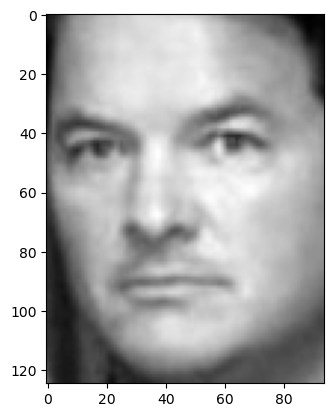

In [5]:
import matplotlib.pyplot as plt
# displays an image, X[10] takes 11th image from dataset, this is flattened vector h*w
plt.imshow(X[10].reshape((h, w)), cmap="gray")
# .reshape((h,w)) 1D -> 2D, cmap="gray" displays in grayscale instead of color
plt.show()

In the code below we now add the noise:

In [6]:
#creates random num generator from NumPy, rng is now an object used to generate rand nums
rng = np.random.RandomState(55)
# generates random noise using normal distribution, scale=0.1 standard deviation of the noise(controls how strong noise is)
# size=X.shape makes noise array same shape as X, so (13233, 11750)
#noise is a matrix of small random values added to image pixels
noise = rng.normal(scale=0.1, size=X.shape)
#adds the random noise to og images. X_noisy is new dataset with noisy images
#each pixel in it is og pixel value + small randomrturbation
X_noisy = X + noise

In [7]:
X.shape

(13233, 11750)

Explain how the `rng.normal()` function works here.  What are the `scale` and `size` parameters?

Here we have an example noisy image:

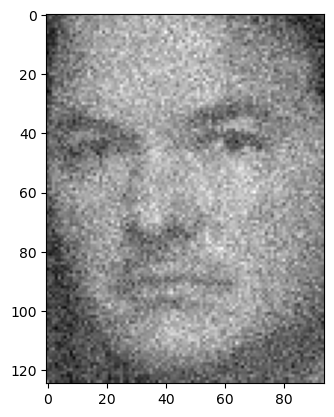

In [8]:
import matplotlib.pyplot as plt
plt.imshow(X_noisy[10].reshape((h, w)), cmap="gray")
plt.show()

Complete the code below to do the PCA fit on the images

In [9]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
n_components = 10 

pca = PCA(n_components = 10)
X_pca = pca.fit_transform(X_noisy)


Check the scikit-learn PCA documentation to see how the `.transform()` and `.inverse_transform()` functions work, write a summary of them below. 

`.transform()`: 

`.inverse_transform():`

The code below uses these functions to:

- transform the images using PCA
- Convert the PCA form of the data back into the original format

In [10]:
pca_data = pca.transform(X_noisy)
X_noisy_pca = pca.inverse_transform(pca_data)

We can plot the image like below, by first reshaping it into the correct shape.

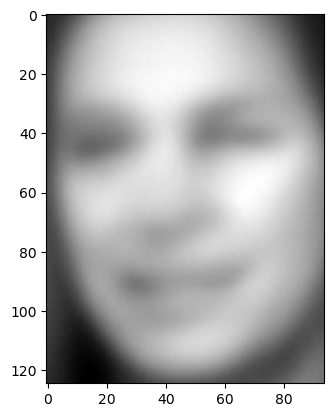

In [11]:
plt.imshow(X_noisy_pca[10].reshape((h, w)), cmap="gray")
plt.show()

Uncomment the code below to see a few different examples of denoising.  Look closely at the subplots in the code and see how it works.

In [12]:
#n_show = 6
#fig, axes = plt.subplots(3, n_show, figsize=(1.5*n_show, 4))
#for i in range(n_show):
#    axes[0, i].imshow(X[i+10].reshape((h, w)), cmap="gray")
#    axes[0, i].set_title("clean")
#    axes[0, i].axis("off")
#
#    axes[1, i].imshow(X_noisy[i+10].reshape((h, w)), cmap="gray")
#    axes[1, i].set_title("noisy")
#    axes[1, i].axis("off")
#

#    axes[882, i].imshow(X_noisy_pca[i+10].reshape((h, w)), cmap="gray")
#    axes[2, i].set_title("denoised")
#    axes[2, i].axis("off")
#
#plt.tight_layout()
#plt.show()

**4 - Image compression with PCA**

Since PCA reduces the dimension of data, it can be used for image compression.

Below we load an image, you can choose your own image if you like.

In [13]:
from matplotlib.image import imread
img = imread('cat.jpg')  # (h, w) grayscale
#h, w = img.shape
X = img

In [14]:
X.shape

(193, 273, 3)

It looks like:

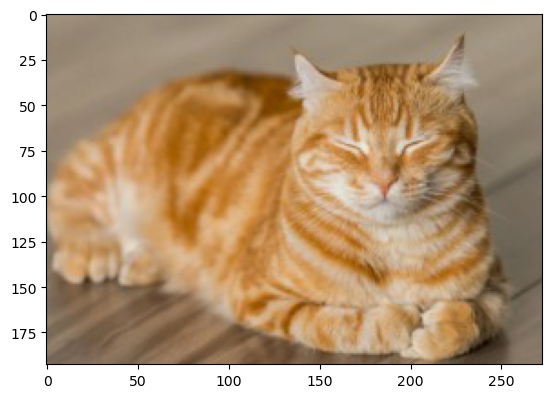

In [15]:
plt.imshow(X, cmap="gray")
plt.show()

The image compression works in the exact same way as the compression.  We reduce to some number of components using PCA, then re-express the image in those components.

Compress the image using PCA and see how the reconstructed image looks as you include more and more components.  Comment on the results.

**5 - t-SNE on digits**

Following the code in the lecture, load the digits data and use t-SNE to visualise the data in a 2D plot.  I've include most of the code below, you can fill in the rest.

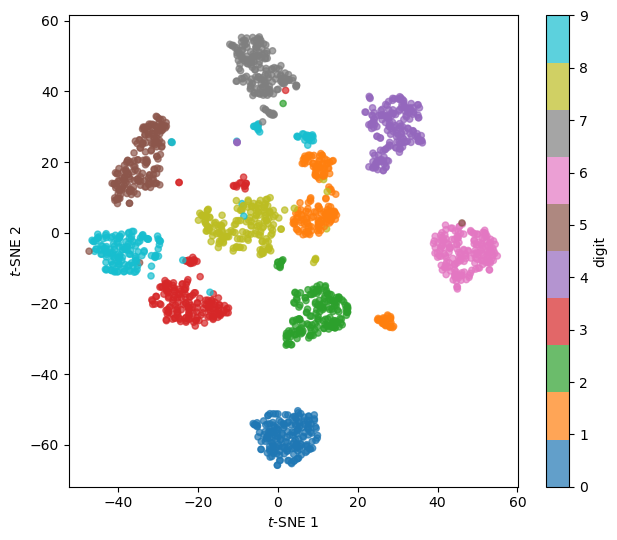

In [16]:
from sklearn.datasets import load_digits #loads handwritten digits dataset (1797 images, 8x8 pixels)
from sklearn.manifold import TSNE

digits = load_digits()
X = digits.data  #(1797, 64)
y = digits.target # digit labels (0-9)

tsne = TSNE(n_components=2, init="random", learning_rate="auto", perplexity=30, random_state=0)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(6.5, 5.5))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab10", s=20, alpha=0.7)
plt.xlabel(r"$t$-SNE 1")
plt.ylabel(r"$t$-SNE 2")
plt.colorbar(scatter, label="digit")
plt.tight_layout()
plt.savefig('digits-tsne.png')
plt.show()

Look at how the scatter plot works here, explain below what each parameter in the plotting function is doing.

`X_tsne[:,0]`:

`X_tsne[:,0]`:

`c`:

`cmap`:

`s`:

`alpha`: